In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1- Customer Data

In [6]:
customers = pd.read_excel("Qbmrbz/customers.xlsx")
customers

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6
3,4,David Garcia,david.garcia@example.com,Male,25,8
4,5,Emma Miller,emma.miller@example.com,Female,41,4
...,...,...,...,...,...,...
95,96,Emily Gonzalez,emily.gonzalez@example.com,Female,38,10
96,97,Emily Rodriguez,emily.rodriguez@example.com,Female,51,3
97,98,Chris Lopez,chris.lopez@example.com,Female,55,10
98,99,Laura Hernandez,laura.hernandez@example.com,Male,41,5


In [7]:
customers.shape

(100, 6)

In [8]:
customers.head()

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6
3,4,David Garcia,david.garcia@example.com,Male,25,8
4,5,Emma Miller,emma.miller@example.com,Female,41,4


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    100 non-null    int64 
 1   CustomerName  100 non-null    object
 2   Email         100 non-null    object
 3   Gender        100 non-null    object
 4   Age           100 non-null    int64 
 5   GeographyID   100 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [5]:
customers.duplicated().sum()

0

In [6]:
customers.isna().sum()

CustomerID      0
CustomerName    0
Email           0
Gender          0
Age             0
GeographyID     0
dtype: int64

In [7]:
customers.Gender.value_counts()

Gender
Female    54
Male      46
Name: count, dtype: int64

In [8]:
customers.Age.min(), customers.Age.max(), customers.Age.mean()

(18, 69, 41.99)

(array([ 8., 14., 10., 13., 13., 10.,  8.,  6., 10.,  8.]),
 array([18. , 23.1, 28.2, 33.3, 38.4, 43.5, 48.6, 53.7, 58.8, 63.9, 69. ]),
 <BarContainer object of 10 artists>)

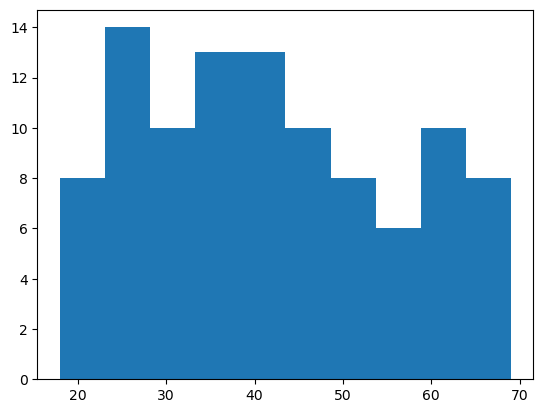

In [9]:
plt.hist(customers.Age)

In [10]:
customers.groupby('Gender')['Age'].mean()

Gender
Female    42.981481
Male      40.826087
Name: Age, dtype: float64

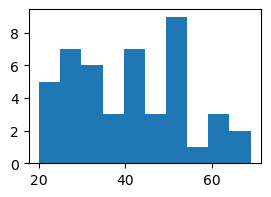

In [11]:
plt.figure(figsize=(3,2))
plt.hist(customers[customers.Gender=='Male']['Age'])
plt.show()

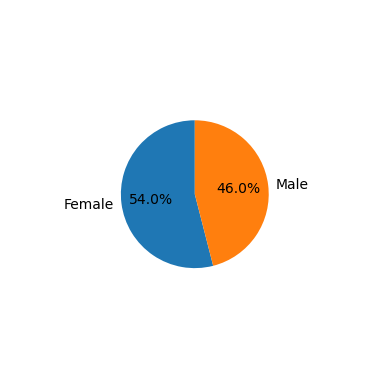

In [12]:
plt.pie(customers.Gender.value_counts(),
        labels=customers.Gender.value_counts().index,
        autopct="%1.1f%%", startangle=90, radius=0.5)
plt.show()

In [13]:
customers['Age_Category']=pd.cut(customers.Age,bins=[18,30,40,50,60,70],
                                 labels=['18-30','31-40','41-50','51-60','61-70'])
Age_Freq =customers.Age_Category.value_counts() #.sort_values(ascending=True)
Age_Freq

Age_Category
31-40    24
18-30    22
41-50    22
51-60    16
61-70    14
Name: count, dtype: int64

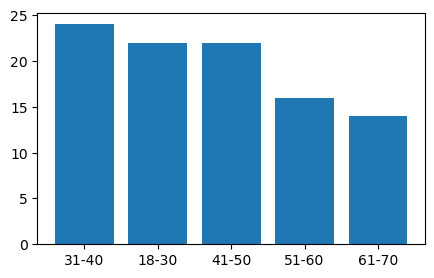

In [14]:
plt.figure(figsize=(5,3))
plt.bar(x=Age_Freq.index,height=Age_Freq.values)
plt.show()

# 3- Customers' Geography Data

In [15]:
geography = pd.read_excel("geography.xlsx")
geography.head(3)

,ID,Region,City
0,1,UK,London
1,2,Germany,Berlin
2,3,France,Paris


In [16]:
customers_updated = pd.merge(customers, geography, how='left', left_on='GeographyID',right_on='ID').drop('ID',axis=1)
customers_updated.head(3)

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,Region,City
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,41-50,Germany,Berlin
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4,31-40,Spain,Madrid
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6,18-30,Netherlands,Amsterdam


### 2- Products Data 

In [17]:
products = pd.read_excel("products.xlsx")
products.head(3)

,ProductID,ProductName,Category,Price
0,1,Running Shoes,Sports,223.75
1,2,Fitness Tracker,Sports,196.68
2,3,Yoga Mat,Sports,485.32


In [18]:
products.ProductName.unique()

array(['Running Shoes', 'Fitness Tracker', 'Yoga Mat', 'Dumbbells',
       'Soccer Ball', 'Tennis Racket', 'Basketball', 'Football Helmet',
       'Baseball Glove', 'Golf Clubs', 'Ski Boots', 'Ice Skates',
       'Swim Goggles', 'Cycling Helmet', 'Climbing Rope', 'Kayak',
       'Surfboard', 'Volleyball', 'Hockey Stick', 'Boxing Gloves'],
      dtype=object)

In [19]:
products.Category.unique()

array(['Sports'], dtype=object)

In [20]:
products.duplicated().sum()

0

In [21]:
products.isna().sum()

ProductID      0
ProductName    0
Category       0
Price          0
dtype: int64

In [22]:
products.shape

(20, 4)

# 4- Customers' Review Data

In [23]:
reviews  = pd.read_excel("customer_reviews.xlsx")
reviews.head(3)

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText
0,1,77,18,2023-12-23,3,"Average experience, nothing special."
1,2,80,19,2024-12-25,5,The quality is top-notch.
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.


In [24]:
reviews_updated = pd.merge(reviews, customers_updated, how='left', on='CustomerID')

reviews_updated  =pd.merge(reviews_updated, products, how='left', on='ProductID')
reviews_updated.head(3)

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText,CustomerName,Email,Gender,Age,GeographyID,Age_Category,Region,City,ProductName,Category,Price
0,1,77,18,2023-12-23,3,"Average experience, nothing special.",David Lopez,david.lopez@example.com,Male,53,4,51-60,Spain,Madrid,Volleyball,Sports,42.80
1,2,80,19,2024-12-25,5,The quality is top-notch.,Laura Jones,laura.jones@example.com,Female,25,6,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.,Olivia Miller,olivia.miller@example.com,Male,36,3,31-40,France,Paris,Swim Goggles,Sports,145.97


In [25]:
reviews_updated.drop(['CustomerID','ProductID','Email','GeographyID'],axis=1,inplace=True)
reviews_updated

,ReviewID,ReviewDate,Rating,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,ProductName,Category,Price
0,1,2023-12-23,3,"Average experience, nothing special.",David Lopez,Male,53,51-60,Spain,Madrid,Volleyball,Sports,42.80
1,2,2024-12-25,5,The quality is top-notch.,Laura Jones,Female,25,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83
2,3,2025-01-26,4,Five stars for the quick delivery.,Olivia Miller,Male,36,31-40,France,Paris,Swim Goggles,Sports,145.97
3,4,2025-04-21,3,"Good quality, but could be cheaper.",Olivia Smith,Female,24,18-30,Sweden,Stockholm,Climbing Rope,Sports,410.17
4,5,2023-07-16,3,"Average experience, nothing special.",Sarah Martinez,Female,62,61-70,Belgium,Brussels,Fitness Tracker,Sports,196.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,1359,2023-05-25,3,Not worth the money.,Emily Davis,Female,18,NaN,Switzerland,Zurich,Dumbbells,Sports,26.21
1359,1360,2023-11-13,2,"Average experience, nothing special.",Jane Williams,Male,34,31-40,Austria,Vienna,Ice Skates,Sports,37.56
1360,1361,2023-03-07,5,Customer support was very helpful.,Emily Gonzalez,Female,38,31-40,Austria,Vienna,Climbing Rope,Sports,410.17
1361,1362,2025-12-03,1,Product did not meet my expectations.,Laura Hernandez,Male,41,41-50,Italy,Rome,Fitness Tracker,Sports,196.68


In [26]:
reviews.duplicated().sum()

0

In [27]:
reviews.isna().sum()

ReviewID      0
CustomerID    0
ProductID     0
ReviewDate    0
Rating        0
ReviewText    0
dtype: int64

# 5- Customers' Engagement Data

In [28]:
engagement = pd.read_excel("engagement_data.xlsx")
engagement.head()

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,ViewsClickCombined
0,1,39,Blog,190,2023-08-30,1,9,1883-671
1,2,48,Blog,114,2023-03-28,18,20,5280-532
2,3,16,video,32,2023-12-08,7,14,1905-204
3,4,43,Video,17,2025-01-21,19,20,2766-257
4,5,16,newsletter,306,2024-02-21,6,15,5116-1524


In [29]:
engagement['Views'] = engagement.ViewsClickCombined.str.split("-").str[0]
engagement['Clicks'] = engagement.ViewsClickCombined.str.split("-").str[1]
engagement.drop('ViewsClickCombined',inplace=True,axis=1)

In [30]:
engagement.head()


,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks
0,1,39,Blog,190,2023-08-30,1,9,1883,671
1,2,48,Blog,114,2023-03-28,18,20,5280,532
2,3,16,video,32,2023-12-08,7,14,1905,204
3,4,43,Video,17,2025-01-21,19,20,2766,257
4,5,16,newsletter,306,2024-02-21,6,15,5116,1524


In [31]:
engagement.head()

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks
0,1,39,Blog,190,2023-08-30,1,9,1883,671
1,2,48,Blog,114,2023-03-28,18,20,5280,532
2,3,16,video,32,2023-12-08,7,14,1905,204
3,4,43,Video,17,2025-01-21,19,20,2766,257
4,5,16,newsletter,306,2024-02-21,6,15,5116,1524


In [32]:
engagement_updated = pd.merge(engagement,products[['ProductID', 'ProductName']],how='left', on='ProductID')
engagement_updated

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks,ProductName
0,1,39,Blog,190,2023-08-30,1,9,1883,671,Baseball Glove
1,2,48,Blog,114,2023-03-28,18,20,5280,532,Boxing Gloves
2,3,16,video,32,2023-12-08,7,14,1905,204,Cycling Helmet
3,4,43,Video,17,2025-01-21,19,20,2766,257,Boxing Gloves
4,5,16,newsletter,306,2024-02-21,6,15,5116,1524,Climbing Rope
...,...,...,...,...,...,...,...,...,...,...
4618,4619,31,Video,270,2023-05-21,3,19,8115,1872,Hockey Stick
4619,4620,46,newsletter,209,2023-07-17,8,4,1273,516,Dumbbells
4620,4621,10,video,78,2023-05-24,20,7,1609,599,Basketball
4621,4622,6,socialmedia,50,2024-04-14,18,2,3052,374,Fitness Tracker


In [33]:
engagement.duplicated().sum()

0

In [34]:
engagement.isna().sum()

EngagementID      0
ContentID         0
ContentType       0
Likes             0
EngagementDate    0
CompaignID        0
ProductID         0
Views             2
Clicks            2
dtype: int64

# Customers' Journey

In [35]:
# Load the dataset
customer_journey_df = pd.read_excel('customer_journey.xlsx')
customer_journey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   JourneyID   4011 non-null   int64         
 1   CustomerID  4011 non-null   int64         
 2   ProductId   4011 non-null   int64         
 3   VisitDate   4011 non-null   datetime64[ns]
 4   Stage       4011 non-null   object        
 5   Action      4011 non-null   object        
 6   Duration    3398 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 219.5+ KB


In [36]:
customer_journey_df.head()

,JourneyID,CustomerID,ProductId,VisitDate,Stage,Action,Duration
0,1,64,18,2024-06-10,Checkout,Drop-off,NaN
1,2,94,11,2025-07-09,Checkout,Drop-off,NaN
2,3,34,8,2024-06-14,ProductPage,View,235.0
3,4,33,18,2025-05-28,Checkout,Drop-off,NaN
4,5,91,10,2023-02-11,Homepage,Click,156.0


In [37]:
customer_journey_df.Stage.unique()

array(['Checkout', 'ProductPage', 'Homepage', 'productpage', 'homepage',
       'checkout'], dtype=object)

In [38]:
customer_journey_df.Stage = customer_journey_df.Stage.str.lower()

In [39]:
customer_journey_df.Action.unique()

array(['Drop-off', 'View', 'Click', 'Purchase'], dtype=object)

In [40]:
customer_journey_df.Duration.isna().sum()

613

In [41]:
customer_journey_df.duplicated().sum()

79

In [42]:
customer_journey_df[customer_journey_df.duplicated()].sort_values(by='JourneyID')

,JourneyID,CustomerID,ProductId,VisitDate,Stage,Action,Duration
3993,23,58,1,2023-07-05,homepage,View,48.0
3997,97,92,19,2025-05-26,homepage,View,203.0
3951,151,79,20,2023-11-04,checkout,Purchase,298.0
3939,203,44,11,2024-12-28,homepage,View,230.0
3940,404,30,13,2023-04-22,homepage,View,112.0
...,...,...,...,...,...,...,...
3967,3781,54,8,2025-04-14,homepage,View,250.0
3983,3852,99,5,2025-09-07,productpage,View,205.0
3941,3881,58,18,2024-08-27,checkout,Drop-off,NaN
3938,3912,99,9,2025-06-13,homepage,Click,143.0


In [43]:
customer_journey_df.drop_duplicates(keep='first', inplace=True)

In [44]:
customer_journey_df.duplicated().sum()

0

In [45]:
customer_journey_df.isna().sum()

JourneyID       0
CustomerID      0
ProductId       0
VisitDate       0
Stage           0
Action          0
Duration      598
dtype: int64

In [46]:
customer_journey_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3932 entries, 0 to 3931
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   JourneyID   3932 non-null   int64         
 1   CustomerID  3932 non-null   int64         
 2   ProductId   3932 non-null   int64         
 3   VisitDate   3932 non-null   datetime64[ns]
 4   Stage       3932 non-null   object        
 5   Action      3932 non-null   object        
 6   Duration    3334 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 245.8+ KB


In [47]:
# Convert VisitDate to datetime and Duration to numeric
customer_journey_df['VisitDate'] = pd.to_datetime(customer_journey_df['VisitDate'], errors='coerce')
customer_journey_df['Duration'] = pd.to_numeric(customer_journey_df['Duration'], errors='coerce')

In [48]:
customer_journey_df

,JourneyID,CustomerID,ProductId,VisitDate,Stage,Action,Duration
0,1,64,18,2024-06-10,checkout,Drop-off,NaN
1,2,94,11,2025-07-09,checkout,Drop-off,NaN
2,3,34,8,2024-06-14,productpage,View,235.0
3,4,33,18,2025-05-28,checkout,Drop-off,NaN
4,5,91,10,2023-02-11,homepage,Click,156.0
...,...,...,...,...,...,...,...
3927,3928,39,5,2025-04-06,productpage,View,221.0
3928,3929,64,6,2025-08-06,productpage,View,55.0
3929,3930,2,9,2024-09-22,homepage,Click,260.0
3930,3931,67,20,2023-06-26,homepage,View,205.0


In [49]:
# it calculates the average duration and fill against each group occurance
customer_journey_df['Duration'] = customer_journey_df.groupby('VisitDate')['Duration'].transform('mean')

In [50]:
customer_journey_df.Duration.fillna(
    customer_journey_df.groupby('VisitDate')['Duration'].transform('mean'), inplace=True)

C:\Users\Nasir Hussain\AppData\Local\Temp\ipykernel_17060\786020041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_journey_df.Duration.fillna(


In [51]:
customer_journey_updated = customer_journey_df

In [52]:
customer_journey_updated.isna().sum()

JourneyID      0
CustomerID     0
ProductId      0
VisitDate      0
Stage          0
Action         0
Duration      31
dtype: int64

In [54]:
customer_journey_updated.to_csv('customer_journey_updated.csv')